In [29]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()
from pydantic import BaseModel, Field
import os

api_key = os.getenv("GOOGLE_API_KEY")

if os.environ['GOOGLE_API_KEY']:
    print("Google api key is set")
else:
    raise ValueError("Gemini API key is not set")


llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", google_api_key=api_key, temperature=0.7)

Google api key is set


In [ ]:
from database import DatabaseManager
from langchain_core.tools import tool
from typing import Literal

db = DatabaseManager()

from datetime import datetime
import dateparser


def normalize_date(expense_date: str) -> str:
    """
    Convert natural language dates into YYYY-MM-DD format.
    """

    if not expense_date:
        return datetime.today().strftime("%Y-%m-%d")

    parsed_date = dateparser.parse(
        expense_date,
        settings={
            "PREFER_DATES_FROM": "past"
        }
    )

    if parsed_date is None:
        raise ValueError(f"Invalid date: {expense_date}")

    return parsed_date.strftime("%Y-%m-%d")

@tool
def add_expense_tool(amount: float, category: Literal[
        "Food",
        "Transport",
        "Shopping",
        "Bills",
        "Entertainment",
        "Healthcare",
        "Education",
        "Travel",
        "Other",
    ], description: str, expense_date: str) -> str:
    """
    Use this tool whenever the user wants to add, record, log, or save a new expense.
    Args:
        amount: Total amount spent
        category: Category of the expenditure
        description: description of the category
        expense_date: day on which money spent.
                      Convert natural language dates like "today",
                      "yesterday", or "last Monday" into YYYY-MM-DD when possible.
    """

    expense_date = normalize_date(expense_date)
    db.add_expense(amount, category, description, expense_date)
    return f"Expense of ₹{amount} added successfully."

@tool
def view_expense_tool() -> str:
    """
Use this tool only when the user asks to view, list, display, or show all expenses.

Do NOT use this tool for adding, updating, or deleting expenses.
"""
    expense = db.get_expense()
    return f"Fetched records: {expense}"

@tool
def view_expense_by_category_tool(category: Literal[
        "Food",
        "Transport",
        "Shopping",
        "Bills",
        "Entertainment",
        "Healthcare",
        "Education",
        "Travel",
        "Other",
    ]) -> str:
    """
    Use this tool when the user wants to view expenses for a specific category.

    Examples:
- Show my food expenses.
- List transport expenses.
- Display shopping expenses.

    Args:
        category: Category of the expenditure
            
    """
    expense_by_category = db.get_expense_by_category(category)
    return f"Fetched Records: {expense_by_category}"

@tool
def update_expense_tool(expense_id: int, amount: float | None = None, category: Literal[
        "Food",
        "Transport",
        "Shopping",
        "Bills",
        "Entertainment",
        "Healthcare",
        "Education",
        "Travel",
        "Other",
    ] | None = None, description: str | None = None, expense_date: str | None = None) -> str:
    """
    Tool to Update Expenses of user
    Args:
        expense_id: id of the expense record stored
        amount: Total amount spent
        category: Category  of the expenditure
        description: description of the category
        expense_date: Date of the expense in YYYY-MM-DD format.
                      Convert natural language dates like "today",
                      "yesterday", or "last Monday" into YYYY-MM-DD when possible.
    """
    if expense_date:
        expense_date = normalize_date(expense_date)
        
    db.update_expense(amount, category, description, expense_date, expense_id)

    return "Record Updated Successfully"

@tool
def delete_expense_tool(expense_id: int) -> str:
    """
    Tool to Delete Expenses of user
    Args:
        expense_id: id of the expense record stored
    """
    db.delete_expense(expense_id)

    return "Record deleted Succesfully"

In [31]:
tools = [add_expense_tool, view_expense_tool, view_expense_by_category_tool, update_expense_tool, delete_expense_tool]

llm_with_tools = llm.bind_tools(tools)

In [32]:
from typing import TypedDict, List, Annotated
from langchain_core.messages import BaseMessage, ToolMessage, HumanMessage
from langgraph.graph.message import add_messages

class graph_schema(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]

In [ ]:


def llm_node(state: graph_schema) -> graph_schema:
    query = state['messages']
    response = llm_with_tools.invoke(query)
    
    return {
        "messages": [response]
    }

def tool_node(state: graph_schema) -> graph_schema:
    query = state['messages']

    tool_by_name = {tool.name: tool for tool in tools}
    tool_result = []
    for tool_call in query[-1].tool_calls:
        tool = tool_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        tool_result.append(ToolMessage(content=str(observation), tool_call_id=tool_call["id"]))

    return {
        "messages": tool_result
    }

def tool_needed(state: graph_schema) -> str:
    messages = state["messages"]
    if messages[-1].tool_calls:
        return "tool_node"
    else:
        return "end"
    

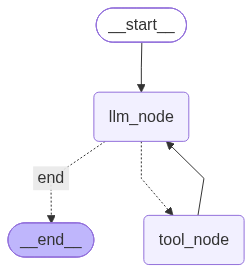

In [34]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("llm_node", llm_node)
graph.add_node("tool_node", tool_node)

graph.add_edge(START, "llm_node")
graph.add_conditional_edges("llm_node", tool_needed, {"tool_node": "tool_node", "end": END})
graph.add_edge("tool_node", "llm_node")
graph.add_edge("llm_node", END)

expense_tracker_graph = graph.compile()
expense_tracker_graph

In [35]:
result = expense_tracker_graph.invoke({"messages": [HumanMessage(content = "Update expense on lunch of 31 July 2026 to 400")]})

result

{'messages': [HumanMessage(content='Update expense on lunch of 31 July 2026 to 400', additional_kwargs={}, response_metadata={}, id='fac9890f-09d9-4dfd-96f8-993962b40bbe'),
  AIMessage(content=[{'type': 'text', 'text': "Could you please provide the ID of the expense you would like to update? I can set the amount to 400, change the category to 'Food', and set the date to 2026-07-31.", 'extras': {'signature': 'Cr4IARFNMg+1BqlnJPAnNoRR/q9ljVLOsQSIYCXHWc7ZUpcTGw++PoLl48gvyPBBcGq629SKZOc3ARrR1CLjGEQj0YMsIr96JwiHsj0OmmMR5dsYM6yMqL9x1szvpaH90ey/FwkWjhlrTGwVSxpRSs0PfMtCy+AQuQxEKP2r+PlPx9XHdqPkoeeb4tv37Cxuo/uxAAPGLs2wFxtRKKjjOViyBmDaAsE+4+bP6jQCeLulq65o5TDzBocIFUuNKXwCDWuNxXeJWMc0WooK8zhZbZkD5fp5ZUnMWrcW7Htp9FMmCbJhy5hDto87URnYU3DmHOeIK7u8fcOW41lIs7qwXFnwO9j2En7nX6uba+QNGuqnpbJKB281f9ZthT3RX5mUEMs7snMZFIBe+Y32/6uoTpceZrMr0Th6XMoVDAV3ZfgO7guZo0i63uoJerfvC7tHpJya1gv6vXS2uapWKdp1m8aDr4Amfi1luRKiYoS2FK7QQGasPMvIyr7Fncd6cq1Sb9Q58WlhyynE1I+BXEN6T4iYOyZQiXGX2uF1N20TSalHE7IepbeXOCkoXmdcBB5BG/9V90tBZAc9